**1.EDA**

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/train.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
print("information")
print(df.info())
print("description")
print(df.describe())

information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
description
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std  

In [4]:
null = df.isnull().sum()
null

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop("Cabin", axis=1, inplace=True)

/tmp/ipykernel_969/3791945144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_969/3791945144.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [6]:
null = df.isnull().sum()
null

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [8]:
print(df)
print("info")
print(df.info())

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name  Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    1  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1   
2                               Heikkinen, Miss. Laina    0  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1   
4                             Allen, Mr. William Henry    1  35.0      0   
..                                                 ...  ...   ...    ...   
886        

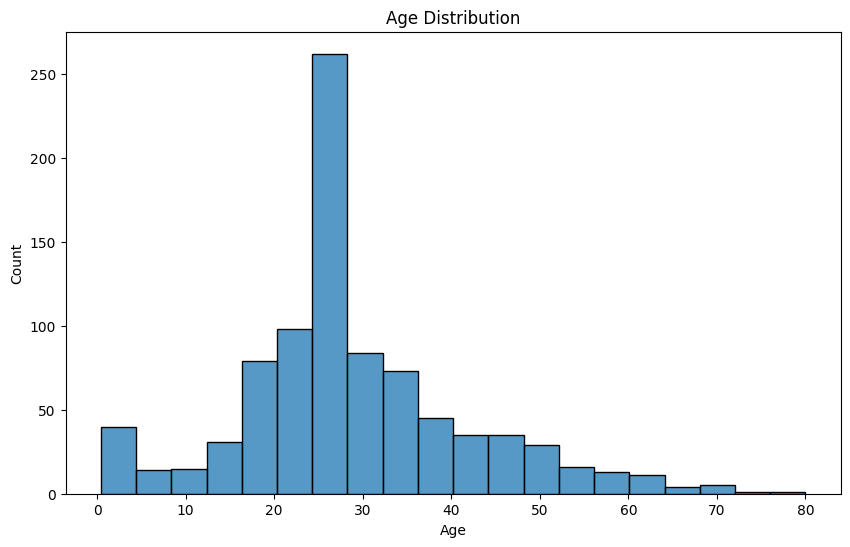

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

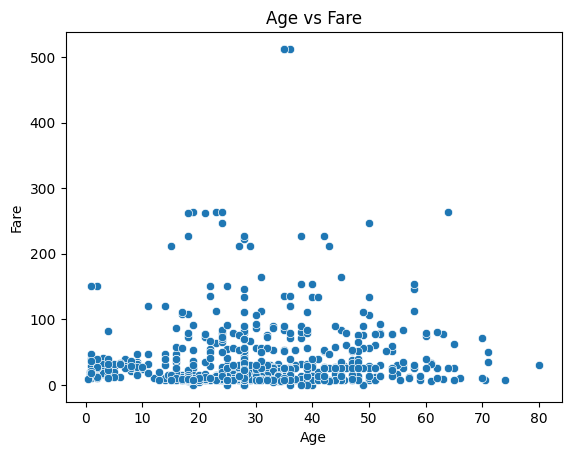

In [10]:
sns.scatterplot(x="Age", y="Fare", data=df)
plt.title("Age vs Fare")
plt.show()

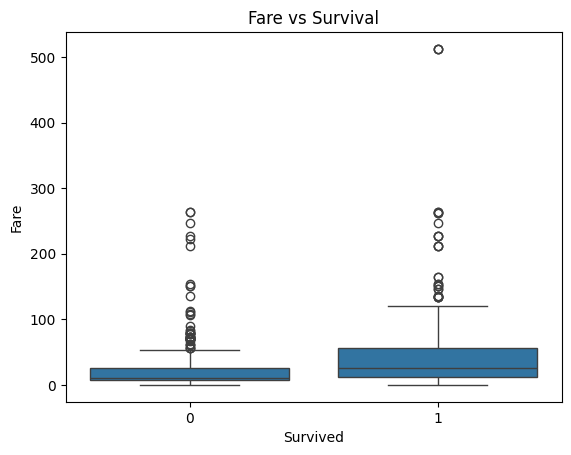

In [11]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

In [12]:
print("average")
print(df["Age"].mean())
print(df["Fare"].mean())
print("median")
print(df["Age"].median())
print(df["Fare"].median())
print("standard diviation ")
print(df["Age"].std())
print(df["Fare"].std())


average
29.36158249158249
32.204207968574636
median
28.0
14.4542
standard diviation 
13.019696550973194
49.693428597180905


**HYPOTHESIS** **TESTING**

In [13]:
print(df.groupby("Sex")["Survived"].mean())
print(df.groupby("Pclass")["Survived"].mean())
print(df.groupby("Survived")["Fare"].mean())

Sex
0    0.742038
1    0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


2.SIMPLE LINEAR REGRESSION

In [14]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url, index_col=0)
print(df)

        TV  radio  newspaper  sales
1    230.1   37.8       69.2   22.1
2     44.5   39.3       45.1   10.4
3     17.2   45.9       69.3    9.3
4    151.5   41.3       58.5   18.5
5    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
196   38.2    3.7       13.8    7.6
197   94.2    4.9        8.1    9.7
198  177.0    9.3        6.4   12.8
199  283.6   42.0       66.2   25.5
200  232.1    8.6        8.7   13.4

[200 rows x 4 columns]


In [15]:
print(df.isnull().sum())

TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB
None


In [17]:
print(df.describe())

               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


In [18]:
print(df.corr())

                 TV     radio  newspaper     sales
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000


In [19]:
X = df[["TV"]]
y = df[["sales"]]
X
y

,sales
1,22.1
2,10.4
3,9.3
4,18.5
5,12.9
...,...
196,7.6
197,9.7
198,12.8
199,25.5


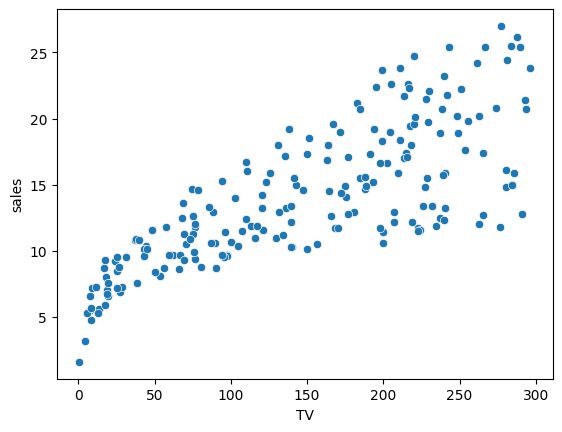

In [20]:
sns.scatterplot(x="TV", y="sales", data=df)
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [24]:
print("MAE")
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)
print("MSE")
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
print("RMSE")
rmse = np.sqrt(mse)
print("RMSE:", rmse)
print("R2")
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

MAE
MAE: 2.444420003751042
MSE
MSE: 10.204654118800956
RMSE
RMSE: 3.194472431998898
R2
R2 Score: 0.6766954295627076


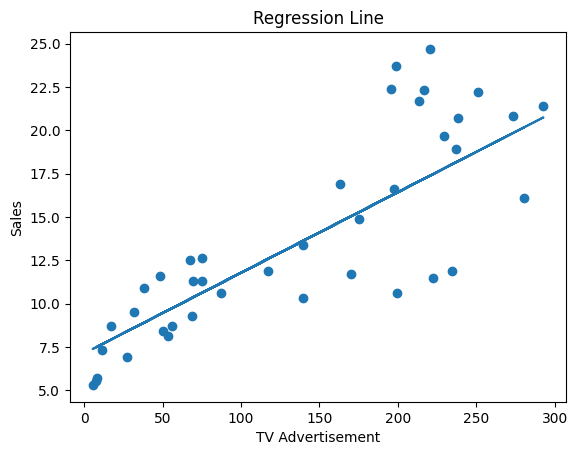

In [25]:
plt.scatter(X_test, y_test)
plt.plot(X_test, predictions)
plt.title("Regression Line")
plt.xlabel("TV Advertisement")
plt.ylabel("Sales")
plt.show()

**3. BASIC CLASSIFICATION MODEL**

In [26]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [28]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [29]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('target',axis=1),df['target'],test_size=0.2)
X
y

,sales
1,22.1
2,10.4
3,9.3
4,18.5
5,12.9
...,...
196,7.6
197,9.7
198,12.8
199,25.5


In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
predictions = model.predict(X_test)

Used LOGISTIC_REGRESSION

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [33]:
print(model.coef_)
print(model.intercept_)

[[-0.30120794 -0.32355323 -0.28178081 -0.33638466 -0.17854565  0.36301193
  -0.7548696  -0.93561363  0.06550035  0.03992046 -1.28488011  0.24272238
  -0.55606917 -0.9597829  -0.21809306  0.68942578  0.13857793 -0.37520074
   0.2925613   0.68547005 -1.01754567 -1.38823631 -0.758058   -0.95661224
  -0.42554515  0.00676807 -0.74956047 -0.86883259 -0.70127005 -0.29877428]]
[0.10453852]


In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [37]:
print("ACCURACY")
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2%}")
print("CONFUSSION MATRIX")
cm = confusion_matrix(y_test, predictions)
print(cm)
print(classification_report(y_test, predictions))

ACCURACY
Accuracy: 99.12%
CONFUSSION MATRIX
[[39  0]
 [ 1 74]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       1.00      0.99      0.99        75

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



**4. SENTIMENT ANALYSIS ON TEXT DATA**

In [38]:
url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
df = pd.read_csv(url)
print(df)

                                                  review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]


In [39]:
print(df.info())
print("discription")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
discription
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000


In [40]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [41]:
import nltk
import re

In [42]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [43]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [44]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = " ".join(words)
    return text

In [45]:
df["review"] = df["review"].apply(clean_text)

In [46]:
print(df["review"].head())

0    one reviewers mentioned watching oz episode yo...
1    wonderful little production br br filming tech...
2    thought wonderful way spend time hot summer we...
3    basically theres family little boy jake thinks...
4    petter matteis love time money visually stunni...
Name: review, dtype: object


In [47]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [48]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    text = " ".join(words)
    return text

In [49]:
from tqdm import notebook
notebook.tqdm.pandas()

In [50]:
df["review"] = df["review"].progress_apply(clean_text)

  0%|          | 0/50000 [00:00<?, ?it/s]

In [51]:
print(df["review"].head())

0    one review mention watch oz episod youll hook ...
1    wonder littl product br br film techniqu unass...
2    thought wonder way spend time hot summer weeke...
3    basic there famili littl boy jake think there ...
4    petter mattei love time money visual stun film...
Name: review, dtype: object


In [59]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["review"])
print(vectorizer.get_feature_names_out())
print(X.shape)

['aa' 'aaa' 'aaaaaaaaaaaahhhhhhhhhhhhhh' ...
 'zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz'
 'zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz'
 'zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz']
(50000, 137562)


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["review"])
print(X.shape)

(50000, 137369)


In [61]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [62]:
predictions = model.predict(X_test)
print(predictions)

[1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 0
 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 1 0 1 0 1 1 1 1 0 1 0
 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 1 0 1 1 1 1 0 0 1
 1 1 1]


In [63]:
sample = ["This movie was absolutely fantastic"]
sample = vectorizer.transform(sample)
prediction = model.predict(sample)
print(prediction)

ValueError: X has 137369 features, but RandomForestClassifier is expecting 30 features as input.

In [64]:
sample = ["worst movie i have ever watched"]
sample = vectorizer.transform(sample)
prediction = model.predict(sample)
print(prediction)

ValueError: X has 137369 features, but RandomForestClassifier is expecting 30 features as input.

ACCURACY
Accuracy: 0.9824561403508771
matrix
[[38  1]
 [ 1 74]]


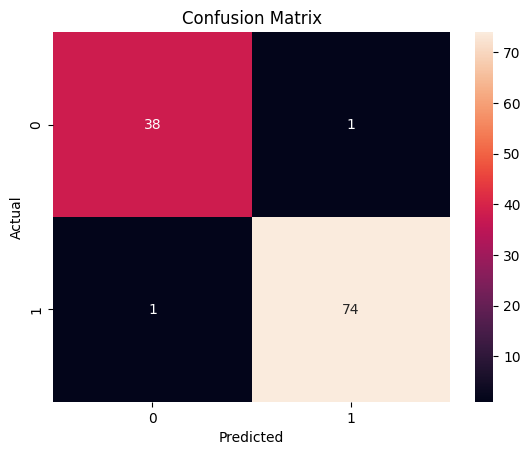

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        39
           1       0.99      0.99      0.99        75

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [65]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
predictions = model.predict(X_test)
print("ACCURACY")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)
print("matrix")
cm = confusion_matrix(y_test, predictions)
print(cm)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(classification_report(y_test, predictions))

**5. Recomandation System**

In [68]:
from sklearn.metrics.pairwise import cosine_similarity
import requests, zipfile, io
print("Downloading MovieLens 100K...")
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/movielens")
ratings = pd.read_csv(
    "/tmp/movielens/ml-100k/u.data",
    sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp']
)
movies = pd.read_csv(
    "/tmp/movielens/ml-100k/u.item",
    sep='|',
    encoding='latin-1',
    usecols=[0, 1],
    names=['movieId', 'title']
)
ratings = ratings.merge(movies, on='movieId')
ratings.drop(columns='timestamp', inplace=True)

print(ratings.shape)
print(ratings.head())
print(f"\nUnique users  : {ratings['userId'].nunique()}")
print(f"Unique movies : {ratings['movieId'].nunique()}")
print(f"Rating range  : {ratings['rating'].min()} – {ratings['rating'].max()}")

(100000, 4)
   userId  movieId  rating                       title
0     196      242       3                Kolya (1996)
1     186      302       3    L.A. Confidential (1997)
2      22      377       1         Heavyweights (1994)
3     244       51       2  Legends of the Fall (1994)
4     166      346       1         Jackie Brown (1997)

Unique users  : 943
Unique movies : 1682
Rating range  : 1 – 5


In [71]:
movie_matrix = ratings.pivot_table(
    index='userId',
    columns='title',
    values='rating')
movie_matrix = movie_matrix.fillna(0)
print(movie_matrix.head())
print(movie_matrix.shape)

title   'Til There Was You (1997)  1-900 (1994)  101 Dalmatians (1996)  \
userId                                                                   
1                             0.0           0.0                    2.0   
2                             0.0           0.0                    0.0   
3                             0.0           0.0                    0.0   
4                             0.0           0.0                    0.0   
5                             0.0           0.0                    2.0   

title   12 Angry Men (1957)  187 (1997)  2 Days in the Valley (1996)  \
userId                                                                 
1                       5.0         0.0                          0.0   
2                       0.0         0.0                          0.0   
3                       0.0         2.0                          0.0   
4                       0.0         0.0                          0.0   
5                       0.0         0.0          

In [72]:
from sklearn.metrics.pairwise import cosine_similarity
user_similarity = cosine_similarity(movie_matrix)
print(user_similarity.shape)

(943, 943)


In [73]:
similarity_df = pd.DataFrame(
    user_similarity,
    index=movie_matrix.index,
    columns=movie_matrix.index)
print(similarity_df.head())

userId       1         2         3         4         5         6         7    \
userId                                                                         
1       1.000000  0.168937  0.048388  0.064561  0.379670  0.429682  0.443097   
2       0.168937  1.000000  0.113393  0.179694  0.073623  0.242106  0.108604   
3       0.048388  0.113393  1.000000  0.349781  0.021592  0.074018  0.067423   
4       0.064561  0.179694  0.349781  1.000000  0.031804  0.068431  0.091507   
5       0.379670  0.073623  0.021592  0.031804  1.000000  0.238636  0.374733   

userId       8         9         10   ...       934       935       936  \
userId                                ...                                 
1       0.320079  0.078385  0.377733  ...  0.372213  0.119860  0.269860   
2       0.104257  0.162470  0.161273  ...  0.147095  0.310661  0.363328   
3       0.084419  0.062039  0.066217  ...  0.033885  0.043453  0.167140   
4       0.188060  0.101284  0.060859  ...  0.054615  0.036784  0

In [75]:
similar_users = similarity_df[1].sort_values(ascending=False)
print(similar_users.head())

userId
1      1.000000
916    0.566293
864    0.549277
457    0.541364
92     0.539415
Name: 1, dtype: float64


In [76]:
def recommend_movies(user_id):
    similar_users = similarity_df[user_id].sort_values(
        ascending=False)
    similar_users = similar_users.drop(user_id)
    top_user = similar_users.index[0]
    recommended_movies = movie_matrix.loc[top_user]
    recommended_movies = recommended_movies[
        recommended_movies >= 4
    ]
    recommended_movies = recommended_movies.sort_values(
        ascending=False
    )
    return recommended_movies.head(10)

In [78]:
print(recommend_movies(4))

title
Conspiracy Theory (1997)       4.0
Cop Land (1997)                4.0
Edge, The (1997)               4.0
English Patient, The (1996)    4.0
Fly Away Home (1996)           4.0
Full Monty, The (1997)         4.0
Gattaca (1997)                 4.0
Ice Storm, The (1997)          4.0
In & Out (1997)                4.0
Liar Liar (1997)               4.0
Name: 750, dtype: float64


# 6. Data Visualization **Dashboard**

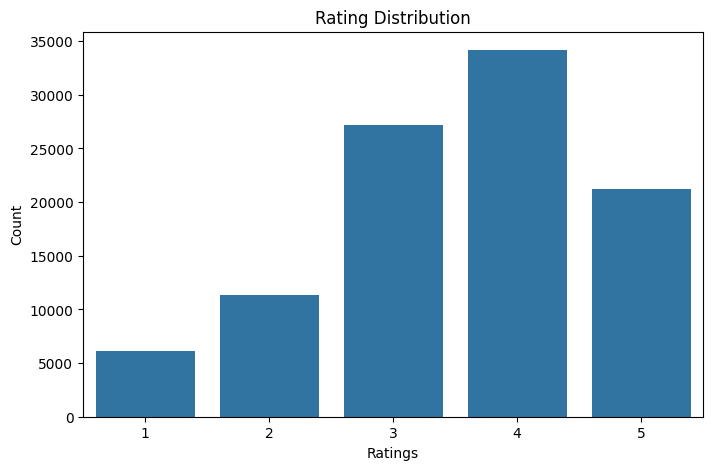

In [81]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=ratings)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

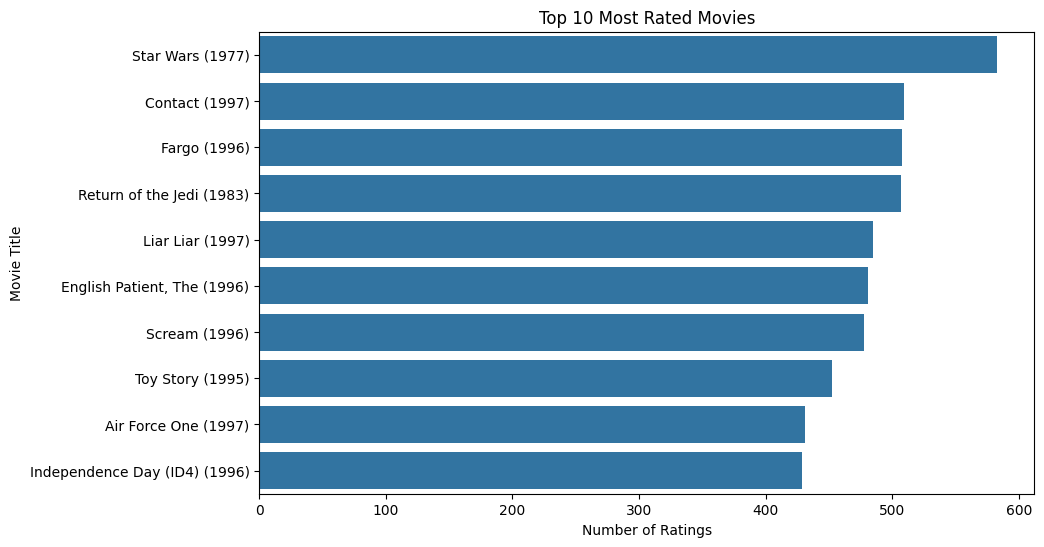

In [82]:
top_movies = ratings['title'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_movies.values,
    y=top_movies.index
)
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()

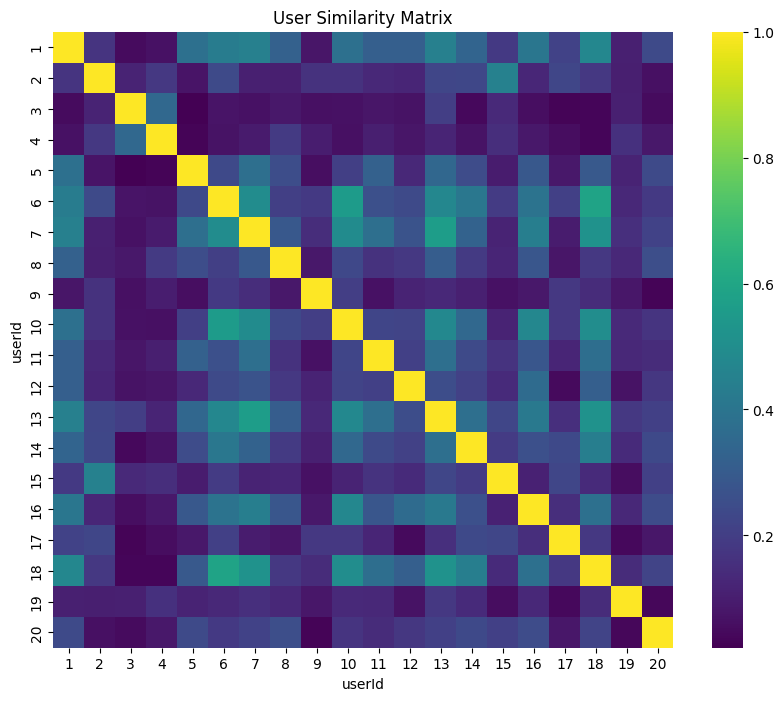

In [83]:
plt.figure(figsize=(10,8))
sns.heatmap(
    similarity_df.iloc[:20, :20],
    cmap='viridis'
)
plt.title("User Similarity Matrix")
plt.show()